# Muchisimocks vs Quijote: P(k), P_gm(k), B(k)

For every LH box under Yin's Quijote directory (`/scratch/kstoreyf/Yin_data/Quijote`),
load precomputed statistics and compare Quijote ground truth to the matching
muchisimocks (map2map) prediction from the same initial conditions. Cosmology and
bias (SHAMe OOD mock) match `code/make_quijote_matched_mocks.py`.

**Top plots:** every LH separately (Quijote black, muchisimocks magenta dashed).
**Residual plot:** mean residual and **±1σ** across LHs.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "code"))

import numpy as np
import matplotlib.pyplot as plt

import data_loader
import paths

%load_ext autoreload
%autoreload 2

## Configuration

These tags must match what was used by `code/make_quijote_matched_mocks.py`. The default
SHAMe mock (`_nbar0.00022`) is the middle nbar from `utils_model.bias_dict_shame`.

NOTE: we may also want to compare the full 512^3 versions later; for now everything
uses the muchisimocks library convention of 512 -> 128 (k-cut + deconvolved).

## LH0663: summed tracer $\delta$ and field residual

Same SHAMe bias as elsewhere: Quijote vs muchisimocks tracer density from `bias_fields_eul_*_deconvolved`, then the fractional residual $(\mathrm{much}-\mathrm{quij})/\mathrm{quij}$ on the **same** grid (mask bins where $|\mathrm{quij}|$ is tiny compared to the box maximum).

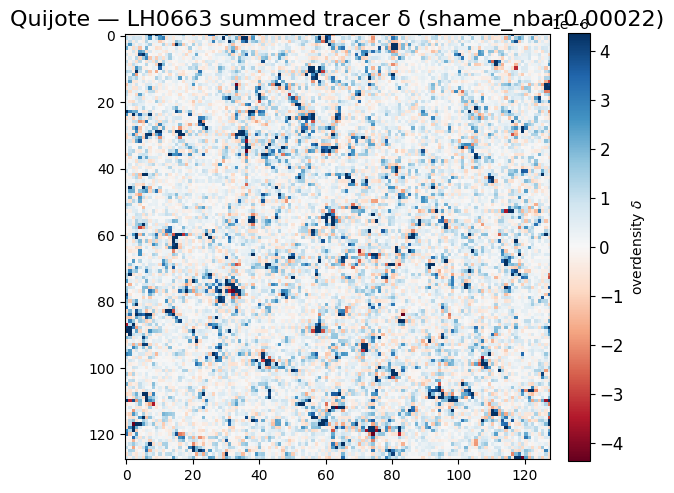

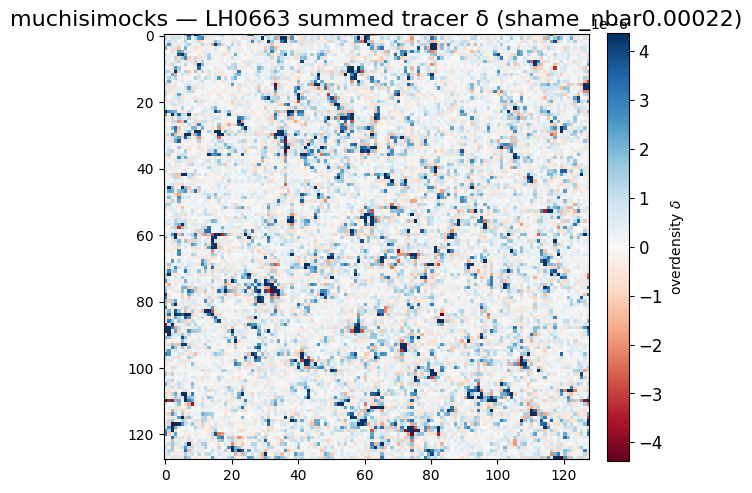

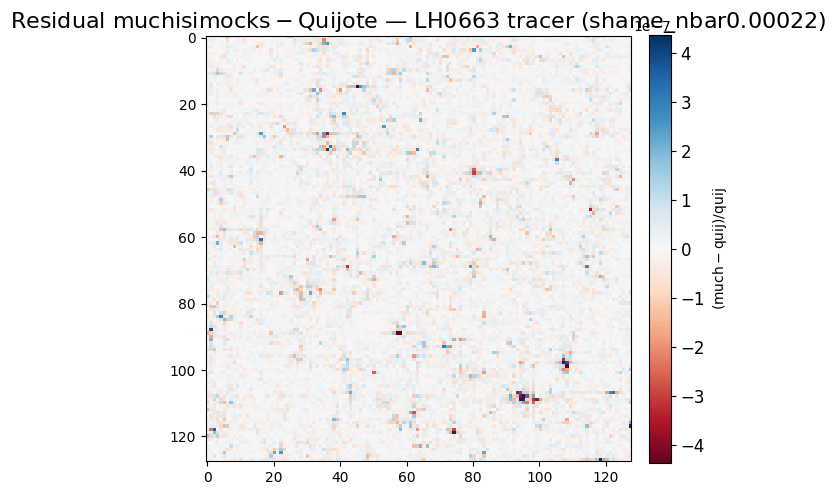

In [2]:
from pathlib import Path

import plotter
import utils_model

DIR_QUIJOTE_BASE_BF = Path("/scratch/kstoreyf/Yin_data/Quijote")
idx_LH_bf = 663
N_GRID_BF = 512  # same as make_quijote_matched_mocks / bias-field shape

tag_mock_shame_bf = "_nbar0.00022"
shame_param_dict_bf = data_loader.load_params_ood("shame", tag_mock_shame_bf)
bias_vector_bf = [shame_param_dict_bf[n] for n in utils_model.biasparam_names_ordered]


def _bfields_path_bf(idx_LH: int, source: str) -> Path:
    return DIR_QUIJOTE_BASE_BF / f"LH{idx_LH:04d}" / f"bias_fields_eul_{source}_deconvolved_{idx_LH:04d}.npy"


tracer_bf = {}
for source, name in (("quijote", "Quijote"), ("muchisimocks", "muchisimocks")):
    fn_b = _bfields_path_bf(idx_LH_bf, source)
    if not fn_b.exists():
        print(f"Missing bias fields: {fn_b}")
        continue
    bfields = np.load(fn_b)
    tracer = utils_model.get_tracer_field(bfields, bias_vector_bf, N_GRID_BF)
    tracer_bf[source] = tracer
    plotter.plot_overdensity_field(
        tracer,
        title=f"{name} — LH{idx_LH_bf:04d} summed tracer δ (shame{tag_mock_shame_bf})",
    )

if "quijote" in tracer_bf and "muchisimocks" in tracer_bf:
    tq, tm = tracer_bf["quijote"], tracer_bf["muchisimocks"]
    # Same symmetric color scale as plot_overdensity_field(Quijote): ±3σ(δ_quij)
    vmax_q = float(3 * np.std(tq)) / 10
    if not np.isfinite(vmax_q) or vmax_q <= 0:
        vmax_q = 1.0
    qscale = float(np.nanmax(np.abs(tq)))
    if not np.isfinite(qscale) or qscale == 0:
        qscale = 1.0
    cut = 1e-8 * qscale
    den = np.where(np.abs(tq) > cut, tq, np.nan)
    #res_bf = (tm - tq) / den
    res_bf = tm - tq
    plotter.plot_field(
        res_bf,
        vmin=-vmax_q,
        vmax=vmax_q,
        title=(
            #f"Residual $(\\mathrm{{much}}-\\mathrm{{quij}})/\\mathrm{{quij}}$ "
            f"Residual $\\mathrm{{muchisimocks}}-\\mathrm{{Quijote}}$ "
            f"— LH{idx_LH_bf:04d} tracer (shame{tag_mock_shame_bf})"
        ),
        overdensity=True,
        label_cbar=r"$(\mathrm{much}-\mathrm{quij})/\mathrm{quij}$",
    )
else:
    print("Skipping field residual: need both Quijote and muchisimocks bias fields.")

In [3]:
tag_mocks = "_quijote_matched"
tag_mock_shame = "_nbar0.00022"
tag_bias = f"shame{tag_mock_shame}"

n_grid_target = 128  # used for bispec normalization

sources = ("quijote", "muchisimocks")

# Set to True to look at the BiasModel-with-damping outputs (matches
# code/data_creation_pipeline.py); False to look at the linear_delta-only
# outputs (matches notebooks/2024-04-03_check_map2map.ipynb). The script
# `code/make_quijote_matched_mocks.py --include_damping` writes the former.
include_damping = False
damping_scale = 0.75
tag_damping = f"_damping{damping_scale}" if include_damping else ""

# Same as make_quijote_matched_mocks.DIR_QUIJOTE_BASE / find_available_lhs()
DIR_QUIJOTE_BASE = Path("/scratch/kstoreyf/Yin_data/Quijote")


def find_available_lhs():
    return sorted(int(d.name[2:]) for d in DIR_QUIJOTE_BASE.glob("LH*") if d.is_dir())


def stat_path(statistic, idx_LH, source):
    """Mirrors `_stat_path` in code/make_quijote_matched_mocks.py."""
    return paths.statistics_dir(statistic, tag_mocks) / \
        f"{statistic}_{idx_LH:04d}_{source}_b{tag_bias}{tag_damping}.npy"


idxs_LH_all = find_available_lhs()
if idxs_LH_all:
    print(f"LH dirs under {DIR_QUIJOTE_BASE}: {len(idxs_LH_all)} boxes "
          f"(indices {idxs_LH_all[0]:04d} … {idxs_LH_all[-1]:04d})")
else:
    print(f"No LH* dirs under {DIR_QUIJOTE_BASE}")
print("Example stat paths (first LH with complete pk/pgm/bispec for both sources):")
for idx in idxs_LH_all:
    if all(stat_path(s, idx, src).exists() for s in ("pk", "pgm", "bispec") for src in sources):
        for stat in ("pk", "pgm", "bispec"):
            for src in sources:
                print(f"  {stat_path(stat, idx, src)}")
        break
else:
    print("  (none complete yet)")

LH dirs under /scratch/kstoreyf/Yin_data/Quijote: 10 boxes (indices 0037 … 1642)
Example stat paths (first LH with complete pk/pgm/bispec for both sources):
  /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_quijote_matched/pk_0037_quijote_bshame_nbar0.00022.npy
  /scratch/kstoreyf/muchisimocks/data/pks_mlib/pks_quijote_matched/pk_0037_muchisimocks_bshame_nbar0.00022.npy
  /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_quijote_matched/pgm_0037_quijote_bshame_nbar0.00022.npy
  /scratch/kstoreyf/muchisimocks/data/pgms_mlib/pgms_quijote_matched/pgm_0037_muchisimocks_bshame_nbar0.00022.npy
  /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_quijote_matched/bispec_0037_quijote_bshame_nbar0.00022.npy
  /scratch/kstoreyf/muchisimocks/data/bispecs_mlib/bispecs_quijote_matched/bispec_0037_muchisimocks_bshame_nbar0.00022.npy


## Load precomputed statistics

Use `data_loader.load_pk` / `load_pgm` / `load_bispec` so we get the same
normalization conventions used everywhere else in the project. For bispec
the loader returns the already-normalized statistic
`norm**3 * weight * b0` (with `norm = n_grid_target**3`).

In [4]:
pk_quij_list, pk_much_list = [], []
pgm_quij_list, pgm_much_list = [], []
B_quij_list, B_much_list = [], []
idxs_loaded = []

for idx_LH in idxs_LH_all:
    need = [
        stat_path("pk", idx_LH, "quijote"),
        stat_path("pk", idx_LH, "muchisimocks"),
        stat_path("pgm", idx_LH, "quijote"),
        stat_path("pgm", idx_LH, "muchisimocks"),
        stat_path("bispec", idx_LH, "quijote"),
        stat_path("bispec", idx_LH, "muchisimocks"),
    ]
    if not all(p.exists() for p in need):
        continue

    k_pk_q, pk_q, _, _ = data_loader.load_pk(str(stat_path("pk", idx_LH, "quijote")))
    k_pk_m, pk_m, _, _ = data_loader.load_pk(str(stat_path("pk", idx_LH, "muchisimocks")))
    k_pgm_q, pgm_q, _, _ = data_loader.load_pgm(str(stat_path("pgm", idx_LH, "quijote")))
    k_pgm_m, pgm_m, _, _ = data_loader.load_pgm(str(stat_path("pgm", idx_LH, "muchisimocks")))
    k123_q, B_q, _, _ = data_loader.load_bispec(
        str(stat_path("bispec", idx_LH, "quijote")), n_grid=n_grid_target)
    k123_m, B_m, _, _ = data_loader.load_bispec(
        str(stat_path("bispec", idx_LH, "muchisimocks")), n_grid=n_grid_target)

    assert np.allclose(k_pk_q, k_pk_m)
    assert np.allclose(k_pgm_q, k_pgm_m)
    assert np.allclose(k123_q, k123_m)

    if idxs_loaded:
        assert np.allclose(k_pk_q, k_pk_ref)
        assert np.allclose(k_pgm_q, k_pgm_ref)
        assert np.allclose(k123_q, k123_ref)

    k_pk_ref, k_pgm_ref, k123_ref = k_pk_q, k_pgm_q, k123_q

    pk_quij_list.append(pk_q)
    pk_much_list.append(pk_m)
    pgm_quij_list.append(pgm_q)
    pgm_much_list.append(pgm_m)
    B_quij_list.append(B_q)
    B_much_list.append(B_m)
    idxs_loaded.append(idx_LH)

if not idxs_loaded:
    raise FileNotFoundError(
        "No LH had complete pk, pgm, and bispec for both quijote and muchisimocks. "
        "Run code/make_quijote_matched_mocks.py or check paths.")

k_pk, k_pgm, k123 = k_pk_ref, k_pgm_ref, k123_ref

pk_stack_quij = np.stack(pk_quij_list, axis=0)
pk_stack_much = np.stack(pk_much_list, axis=0)
pgm_stack_quij = np.stack(pgm_quij_list, axis=0)
pgm_stack_much = np.stack(pgm_much_list, axis=0)
B_stack_quij = np.stack(B_quij_list, axis=0)
B_stack_much = np.stack(B_much_list, axis=0)

n_LH = len(idxs_loaded)
print(f"Loaded {n_LH} LHs with full stats: "
      f"{idxs_loaded[0]:04d} … {idxs_loaded[-1]:04d} (see idxs_loaded)")
print(f"P(k):   stacks {pk_stack_quij.shape},  k in [{k_pk.min():.3f}, {k_pk.max():.3f}]")
print(f"P_gm:   stacks {pgm_stack_quij.shape}, k in [{k_pgm.min():.3f}, {k_pgm.max():.3f}]")
print(f"B(k):   stacks {B_stack_quij.shape}")

Loaded 10 LHs with full stats: 0037 … 1642 (see idxs_loaded)
P(k):   stacks (10, 32),  k in [0.011, 0.378]
P_gm:   stacks (10, 32), k in [0.011, 0.378]
B(k):   stacks (10, 203)


## Plots
Each statistic gets its own figure: **top** — one curve per LH for Quijote (black) and muchisimocks (magenta, dashed). **Bottom** — mean residual across LHs with a **±1σ** band (spread across LHs); legends state this explicitly.

In [5]:
def plot_compare_residual_bands(x, y_stack_quij, y_stack_much, *,
                                x_label, y_label, residual_label,
                                title=None, x_log=True, y_log=True,
                                residual_ylim=None, figsize=(6, 6),
                                threshold_abscissa_math=r"k_\mathrm{max}",
                                threshold_k=None):
    """Top: each LH curve (stack shape (n_LH, n_x)); thinner lines.
    Bottom: mean residual and ±1σ spread across LHs (legend).
    threshold_k: optional length-n_bins array (k or k_max per bin) for computing
    kmax_at_thresh; if None, use x (e.g. P(k) bin centers)."""
    y_stack_quij = np.asarray(y_stack_quij)
    y_stack_much = np.asarray(y_stack_much)
    n_LH = y_stack_quij.shape[0]

    fig, (ax_top, ax_res) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    )

    color_quij, color_much = "black", "magenta"
    lw_indiv = 1.15
    for i in range(n_LH):
        lbl_q = "Quijote (each LH)" if i == 0 else "_nolegend_"
        lbl_m = "muchisimocks (each LH)" if i == 0 else "_nolegend_"
        ax_top.plot(x, y_stack_quij[i], color=color_quij, lw=lw_indiv,
                    alpha=0.85, label=lbl_q)
        ax_top.plot(x, y_stack_much[i], color=color_much, lw=lw_indiv,
                    ls="--", alpha=0.85, label=lbl_m)
    if y_log:
        ax_top.set_yscale("log")
    if x_log:
        ax_top.set_xscale("log")
        ax_res.set_xscale("log")
    ax_top.set_ylabel(y_label)
    ax_top.legend(frameon=False, fontsize=9)
    if title is not None:
        ax_top.set_title(title)

    res_stack = (y_stack_much - y_stack_quij) / y_stack_quij
    res_mean = np.mean(res_stack, axis=0)
    res_std = np.std(res_stack, axis=0, ddof=1) if n_LH > 1 else np.zeros_like(res_mean)
    ax_res.fill_between(
        x, res_mean - res_std, res_mean + res_std,
        facecolor=color_much, alpha=0.28, edgecolor="none",
        label=r"Mean $\pm$ 1$\sigma$ (across LHs)",
    )
    ax_res.plot(
        x, res_mean, color=color_much, lw=1.4, ls="-",
        label=r"Mean residual: $(\mathrm{much}-\mathrm{quij})/\mathrm{quij}$",
    )
    ax_res.axhline(0.0, color=color_quij, lw=0.8)
    thr = 0.005
    ax_res.axhline(thr, color="0.55", lw=0.8, ls="--", zorder=0)
    ax_res.axhline(-thr, color="0.55", lw=0.8, ls="--", zorder=0)
    k_thr_axis = np.asarray(x if threshold_k is None else threshold_k,
                            dtype=float)
    rm_abs = np.abs(res_mean)
    order_thr = np.argsort(k_thr_axis)
    k_sorted = k_thr_axis[order_thr]
    ra_s = rm_abs[order_thr]
    kmax_at_thresh = np.nan
    for i in range(len(k_sorted)):
        if ra_s[i] >= thr:
            break
        kmax_at_thresh = float(k_sorted[i])
    from matplotlib.lines import Line2D
    if np.isfinite(kmax_at_thresh):
        thr_lbl = (
            rf"$\pm {thr}$: $<$0.5\% for ${threshold_abscissa_math} < {kmax_at_thresh:.4g}$"
        )
    else:
        thr_lbl = (
            rf"$\pm {thr}$: no $<$0.5\% prefix vs ${threshold_abscissa_math}$"
        )
    thr_handle = Line2D([0], [0], color="0.55", ls="--", lw=0.8, label=thr_lbl)
    ax_res.set_ylabel(residual_label)
    ax_res.set_xlabel(x_label)
    _h, _l = ax_res.get_legend_handles_labels()
    _h.append(thr_handle)
    _l.append(thr_lbl)
    ax_res.legend(_h[::-1], _l[::-1], frameon=False, fontsize=7, loc="upper right")
    if residual_ylim is not None:
        ax_res.set_ylim(residual_ylim)
    return fig, (ax_top, ax_res)

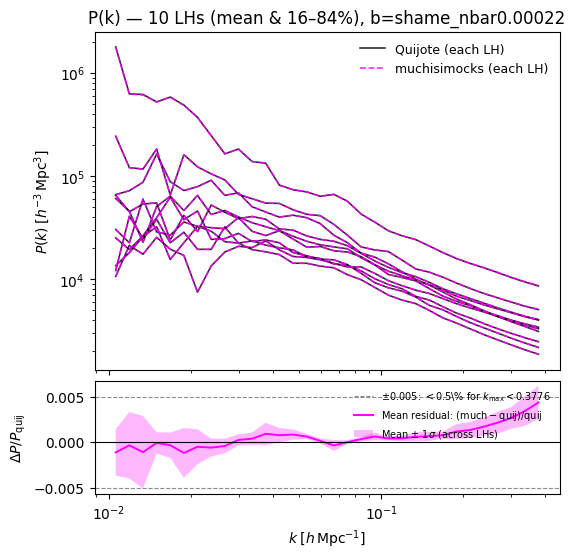

In [6]:
fig, _ = plot_compare_residual_bands(
    k_pk, pk_stack_quij, pk_stack_much,
    x_label=r"$k\;[h\,\mathrm{Mpc}^{-1}]$",
    y_label=r"$P(k)\;[h^{-3}\,\mathrm{Mpc}^3]$",
    residual_label=r"$\Delta P / P_\mathrm{quij}$",
    title=f"P(k) — {n_LH} LHs (mean & 16–84%), b={tag_bias}",
)
plt.show()

In [10]:
k_pk

array([0.01059332, 0.01188766, 0.01334016, 0.01497012, 0.01679924,
       0.01885185, 0.02115526, 0.02374011, 0.02664079, 0.02989589,
       0.03354872, 0.03764786, 0.04224786, 0.0474099 , 0.05320267,
       0.05970323, 0.06699805, 0.07518419, 0.08437056, 0.09467936,
       0.10624773, 0.11922959, 0.13379763, 0.15014567, 0.16849118,
       0.18907824, 0.21218073, 0.23810598, 0.26719891, 0.29984656,
       0.33648324, 0.37759637])

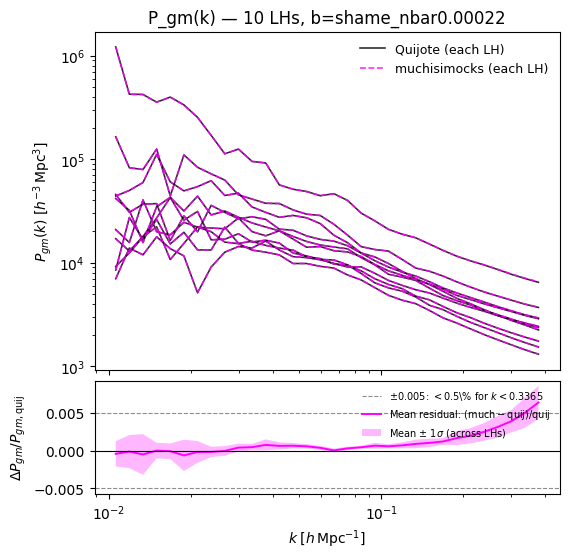

In [7]:
fig, _ = plot_compare_residual_bands(
    k_pgm, pgm_stack_quij, pgm_stack_much,
    x_label=r"$k\;[h\,\mathrm{Mpc}^{-1}]$",
    y_label=r"$P_{gm}(k)\;[h^{-3}\,\mathrm{Mpc}^3]$",
    residual_label=r"$\Delta P_{gm} / P_{gm,\mathrm{quij}}$",
    title=f"P_gm(k) — {n_LH} LHs, b={tag_bias}",
    threshold_abscissa_math=r"k",
)
plt.show()

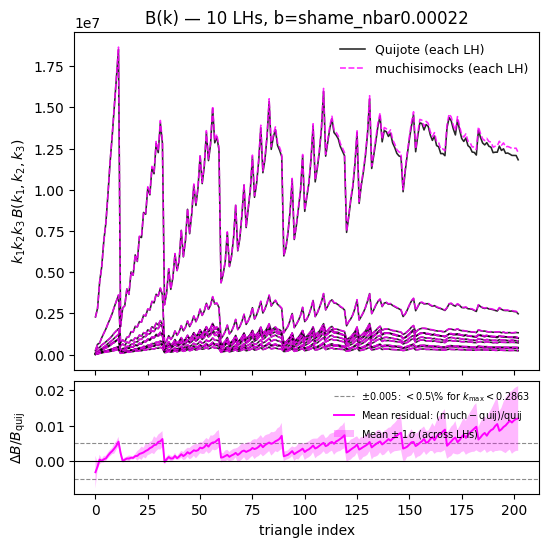

In [8]:
tri_idx = np.arange(B_stack_quij.shape[1])

_k123_thr = np.asarray(k123)
if _k123_thr.shape[0] != 3 and _k123_thr.shape[-1] == 3:
    _k123_thr = _k123_thr.T
_kmax_each_tri = np.max(_k123_thr, axis=0)

fig, _ = plot_compare_residual_bands(
    tri_idx, B_stack_quij, B_stack_much,
    x_label="triangle index",
    y_label=r"$k_1 k_2 k_3 \, B(k_1,k_2,k_3)$",
    residual_label=r"$\Delta B / B_\mathrm{quij}$",
    title=f"B(k) — {n_LH} LHs, b={tag_bias}",
    x_log=False,
    y_log=False,
    threshold_k=_kmax_each_tri,
)
plt.show()

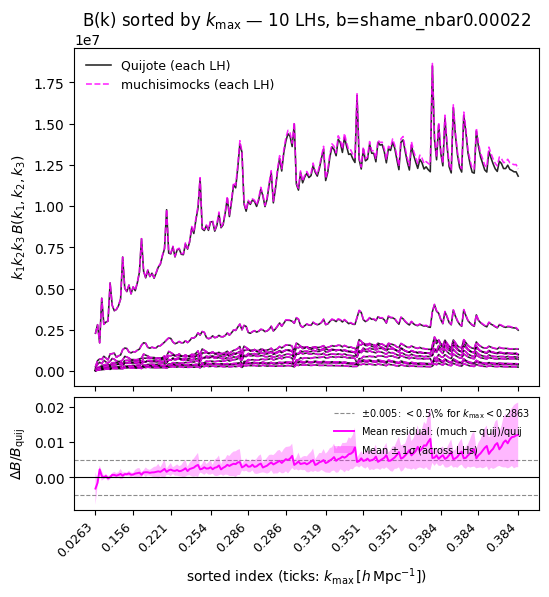

In [9]:
# Same bispectrum comparison: same N points as triangle-index plot, but triangles
# reordered by k_max = max(k1,k2,k3) from k123. x is 0..N-1; tick labels show k_max.
_k123 = np.asarray(k123)
if _k123.shape[0] != 3 and _k123.shape[-1] == 3:
    _k123 = _k123.T
assert _k123.shape[0] == 3, _k123.shape
kmax_tri = np.max(_k123, axis=0)
n_B = B_stack_quij.shape[1]
assert kmax_tri.size == n_B, (kmax_tri.size, n_B)
order = np.lexsort((np.arange(n_B), kmax_tri))
kmax_sorted = kmax_tri[order]
x_ord = np.arange(n_B, dtype=float)
Bq_kmax = B_stack_quij[:, order]
Bm_kmax = B_stack_much[:, order]

fig, (ax_top, ax_res) = plot_compare_residual_bands(
    x_ord, Bq_kmax, Bm_kmax,
    x_label=r"sorted index (ticks: $k_\mathrm{max}\,[h\,\mathrm{Mpc}^{-1}]$)",
    y_label=r"$k_1 k_2 k_3 \, B(k_1,k_2,k_3)$",
    residual_label=r"$\Delta B / B_\mathrm{quij}$",
    title=f"B(k) sorted by $k_\mathrm{{max}}$ — {n_LH} LHs, b={tag_bias}",
    x_log=False,
    y_log=False,
    threshold_k=kmax_sorted,
)
nt = min(12, n_B)
idx_ticks = np.unique(np.linspace(0, n_B - 1, num=nt, dtype=int))
lbls = [f"{kmax_sorted[i]:.3g}" for i in idx_ticks]
for ax in (ax_top, ax_res):
    ax.set_xticks(idx_ticks)
    ax.set_xticklabels(lbls, fontsize=9, rotation=45, ha="right")
plt.show()